In [1]:
import pandas as pd

In [2]:
essay = pd.read_csv('wcpr_essays.csv', encoding='cp1252')
personality = pd.read_csv('wcpr_mypersonality.csv', encoding='cp1252')


In [3]:
# Count number of statuses per user
status_counts = personality.groupby('#AUTHID').size().reset_index(name='num_status')

# Compute 90th percentile
p90_threshold = status_counts['num_status'].quantile(0.90)

print("P90 threshold:", p90_threshold)

# Users <= p90
valid_users = status_counts[status_counts['num_status'] <= p90_threshold]['#AUTHID']

P90 threshold: 98.1


## My essay preprocessing 
I will replace two classes 'y' and 'n' of all columns to 'high' and 'low'.

Besides, I will concat all essay or comment of the author into 1 column 'text'

In [4]:
trait_list = ['cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN']
essay1 = essay.copy()
essay1 = essay1.drop(columns=['#AUTHID'])
essay1 = essay1.rename(columns = {'TEXT' : 'text'})
essay1.head()


,text,cEXT,cNEU,cAGR,cCON,cOPN
0,"Well, right now I just woke up from a mid-day ...",n,y,y,n,y
1,"Well, here we go with the stream of consciousn...",n,n,y,n,n
2,An open keyboard and buttons to push. The thin...,n,y,n,y,y
3,I can't believe it! It's really happening! M...,y,n,y,y,n
4,"Well, here I go with the good old stream of co...",y,n,y,n,y


In [5]:
print(len(essay1))

2468


## My Personality preprocessing
I will replace two classes 'y' and 'n' of all columns to 'high' and 'low'.

Besides, I will concat all essay or comment of the author into 1 column 'text'

In [6]:
personality1 = personality.copy()
personality1 = personality1.rename(columns={'STATUS': 'text'})

# ---------- FULL VERSION (100%) ----------
personality_full = (
    personality1
    .groupby('#AUTHID', as_index=False)
    .agg({
        'text': '\n\n'.join,
        'cEXT': 'first',
        'cNEU': 'first',
        'cAGR': 'first',
        'cCON': 'first',
        'cOPN': 'first'
    })
)

# ---------- P90 FILTERED VERSION ----------
personality_truncated = personality.rename(columns={'STATUS':'text'})

# keep only first p90 statuses per user
personality_truncated = (
    personality_truncated
    .groupby('#AUTHID')
    .head(p90_threshold)
)

personality_p90 = (
    personality_truncated
    .groupby('#AUTHID', as_index=False)
    .agg({
        'text':'\n\n'.join,
        'cEXT':'first',
        'cNEU':'first',
        'cAGR':'first',
        'cCON':'first',
        'cOPN':'first'
    })
)

In [7]:
def transform_label(df):
    for trait in trait_list: 
        df[trait] = df[trait].map({'y' : 'high', 'n' : 'low'})
        
transform_label(essay1)
transform_label(personality_full)
transform_label(personality_p90)

personality_full.drop(columns=['#AUTHID'], inplace=True)
personality_p90.drop(columns=['#AUTHID'], inplace=True)


In [8]:
personality_full.to_csv('processed_mypersonality_full.csv', index=False)
personality_p90.to_csv('processed_mypersonality_p90.csv', index=False)

essay1.to_csv('processed_essay.csv', index=False)

In [9]:
print(len(essay1))
print(len(personality1))

2468
9917


In [10]:
from sklearn.model_selection import train_test_split

sample_df, _ = train_test_split(
    essay1,
    train_size=250,
    stratify=essay1["cAGR"],
    random_state=42
)

sample_df.to_csv('processed250_essay.csv', index=False)

In [11]:
def add_word_length(df):
    df['word_len'] = df['text'].apply(lambda x: len(str(x).split()))
    return df

essay1 = add_word_length(essay1)
personality_full = add_word_length(personality_full)
personality_p90 = add_word_length(personality_p90)

In [12]:
def show_stats(name, df):
    print(f"\n--- {name} ---")
    print("Samples:", len(df))
    print("Min words:", df['word_len'].min())
    print("Max words:", df['word_len'].max())
    print("Average words:", round(df['word_len'].mean(), 2))

show_stats("Essays", essay1)
show_stats("MyPersonality FULL", personality_full)
show_stats("MyPersonality ≤P90", personality_p90)


--- Essays ---
Samples: 2468
Min words: 1
Max words: 2500
Average words: 651.87

--- MyPersonality FULL ---
Samples: 250
Min words: 1
Max words: 4929
Average words: 576.08

--- MyPersonality ≤P90 ---
Samples: 250
Min words: 1
Max words: 2706
Average words: 510.99


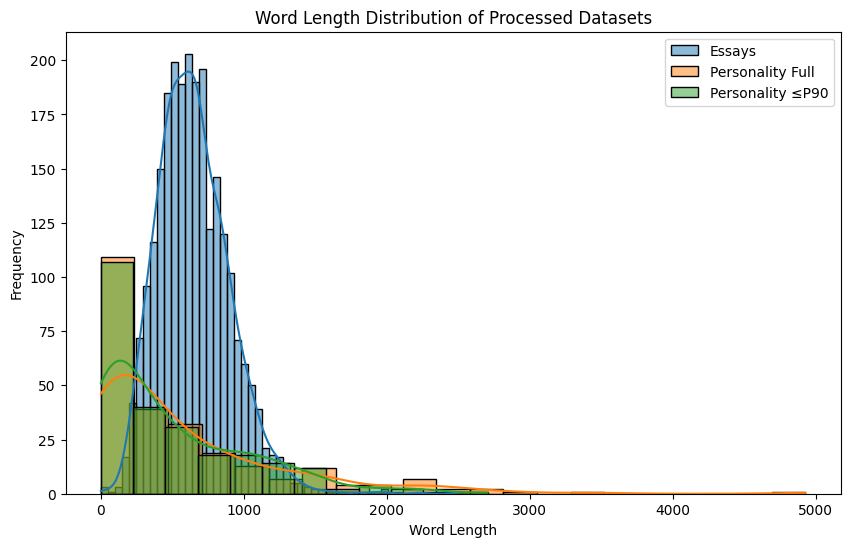

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(essay1['word_len'], label='Essays', kde=True)
sns.histplot(personality_full['word_len'], label='Personality Full', kde=True)
sns.histplot(personality_p90['word_len'], label='Personality ≤P90', kde=True)

plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.title("Word Length Distribution of Processed Datasets")
plt.legend()

plt.show()